## Figure 4

Enviorment: env 1

In [2]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import seaborn as sns
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import balanced_accuracy_score
import textwrap


import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import get_test_pr, get_test_roc

In [3]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

### load NYU data

#### fmf

In [4]:
fmf_probs = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_104.csv")
fmf_probs["id"] = [id.lower() for id in fmf_probs["patient_id"]]
fmf_probs["first_preg"] = [int(val == "Nulliparous") for val in fmf_probs["input_obhist"]]
fmf_probs["prev_pec"] = [int(val == "Parous, prev PE") for val in fmf_probs["input_obhist"]]

In [5]:
fmf_probs["chtn"] = fmf_probs["input_hyp"].astype(int)

#### maternal information

In [6]:
nyu_clinical = pd.read_excel("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/Visionary AI Participant Tracker (1).xlsx")
nyu_clinical["id"] = [id.lower() for id in nyu_clinical["Study ID"].fillna("nan")]
nyu_clinical["aspirin"] = [int("yes" in str(val).lower()) for val in nyu_clinical["Recommended Aspirin?"]]

#### retinal information

In [7]:
nyu_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/nyu/nyu_rg_delivered_testset/"
all_probs = []
all_shap_list = []
for i in range(1, 6):
    path = nyu_path + f"nyu_79_no_repeats_med_pec_pw{i}/meta_all_0.5_oof_bls_pw{i}/XGBoost/"
    name = os.listdir(path)[0]
    with open(path + name, "rb") as f:
        data = pickle.load(f)
        for id in data[5].keys():
            all_shap_list.append({"pw": i,"id": id, "shap": data[5][id]})
    all_probs.append(data[1])
all_probs = pd.DataFrame(all_probs)

In [8]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_cases_051126.pkl", "rb") as f:
    pec = pickle.load(f)

In [9]:
retinal_probs = pd.DataFrame(all_probs.mean(), columns=["retinal"])
retinal_probs["id"] = retinal_probs.index
retinal_probs = retinal_probs.reset_index(drop=True)
retinal_probs = retinal_probs.merge(fmf_probs[["id", "pe_before_delivery_percent", "cohort", "first_preg", "prev_pec", "input_age", "chtn"]], how="outer")
retinal_probs["label"] = (retinal_probs["cohort"] == "case").astype(int)
retinal_probs = retinal_probs.dropna()

### Fig. 4: ROC and PR

In [10]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_evaluation.pkl", "rb") as f:
    eval_data = pickle.load(file=f)
ghtn_cases = eval_data["ghtn"]
chtn_cases = eval_data["chtn"]
final_exclusions = eval_data["ex"]

In [11]:
ids = nyu_clinical[nyu_clinical["aspirin"]== 1]["id"]
ids = list(set(ids) - set(final_exclusions))

In [12]:
a_ids = nyu_clinical[nyu_clinical["aspirin"]== 1]["id"]
a_ids =  list(set(a_ids) - set(final_exclusions))

In [13]:
len(retinal_probs[retinal_probs["id"].isin(ids)].dropna())

33

In [14]:
sum(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["id"].isin(pec))

8

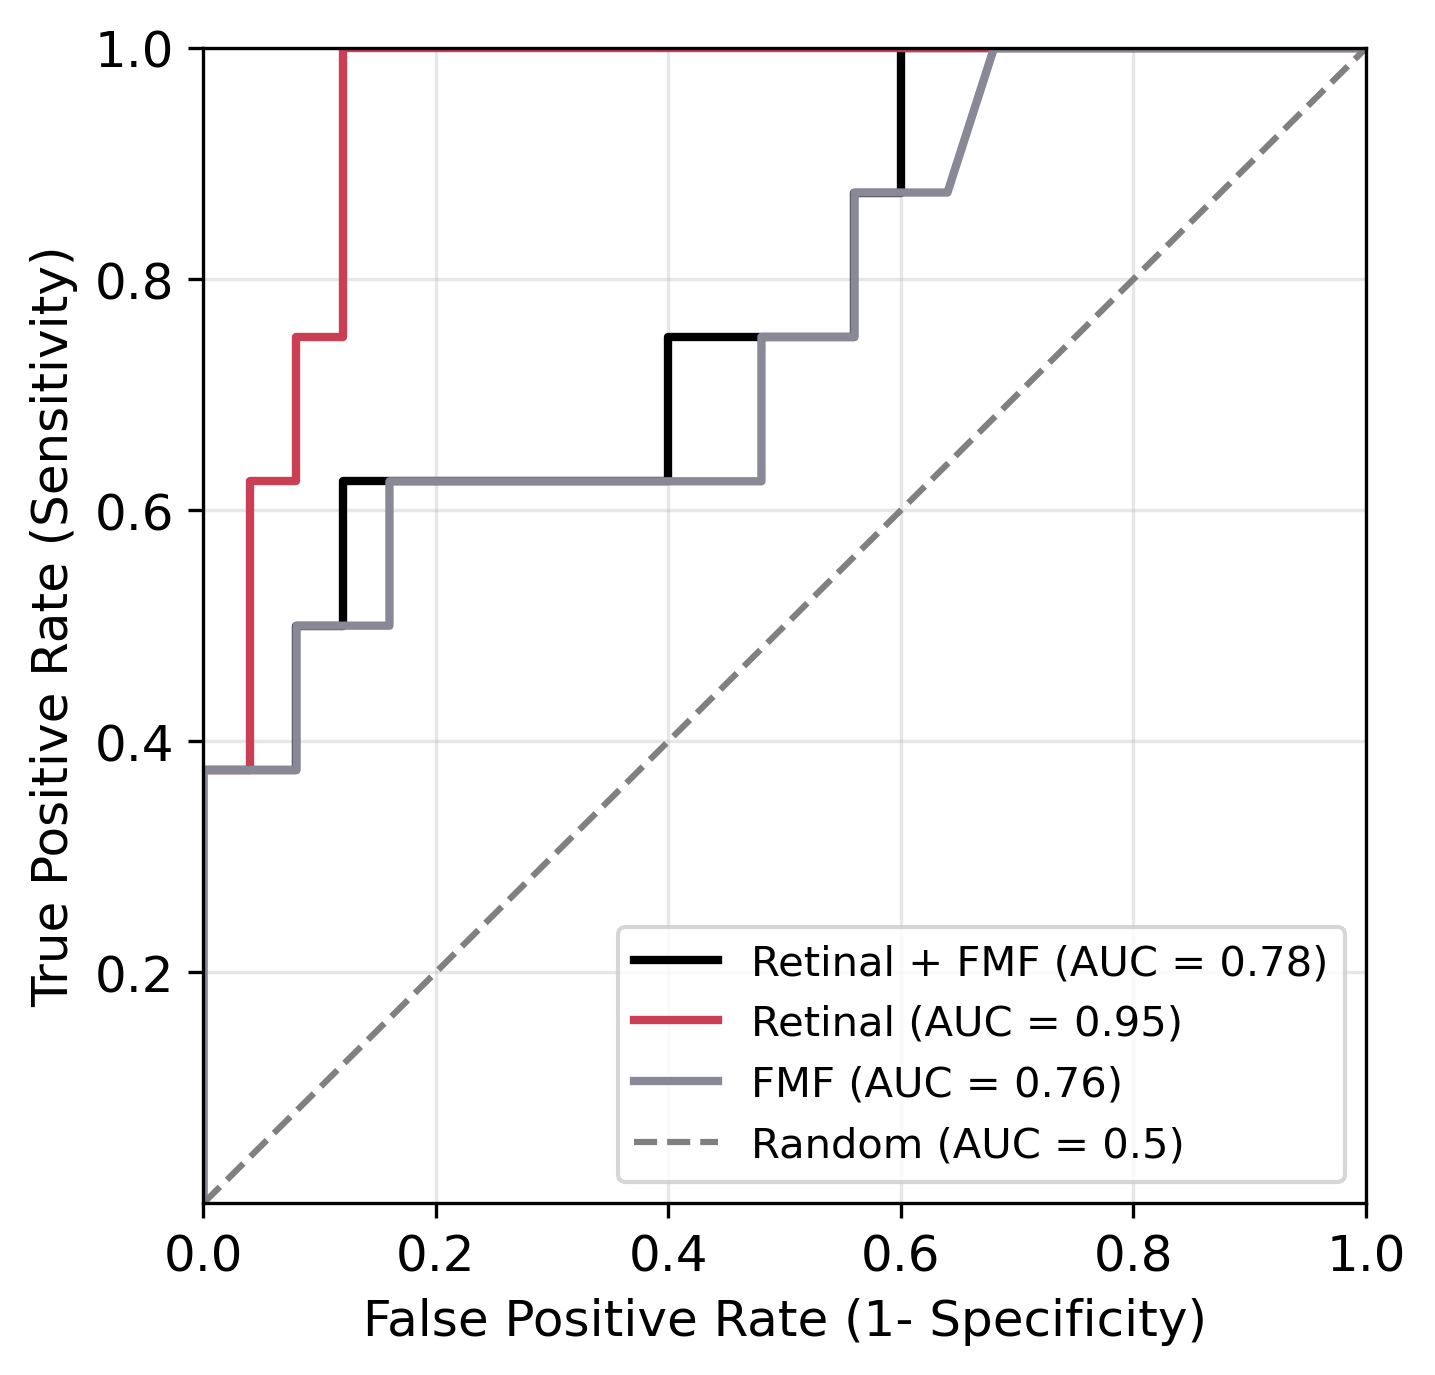

In [15]:

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))

# both
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"] + retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal + FMF", color="black");

# retinal
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")

#fmf
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_4/b_roc.pdf') 

plt.show()

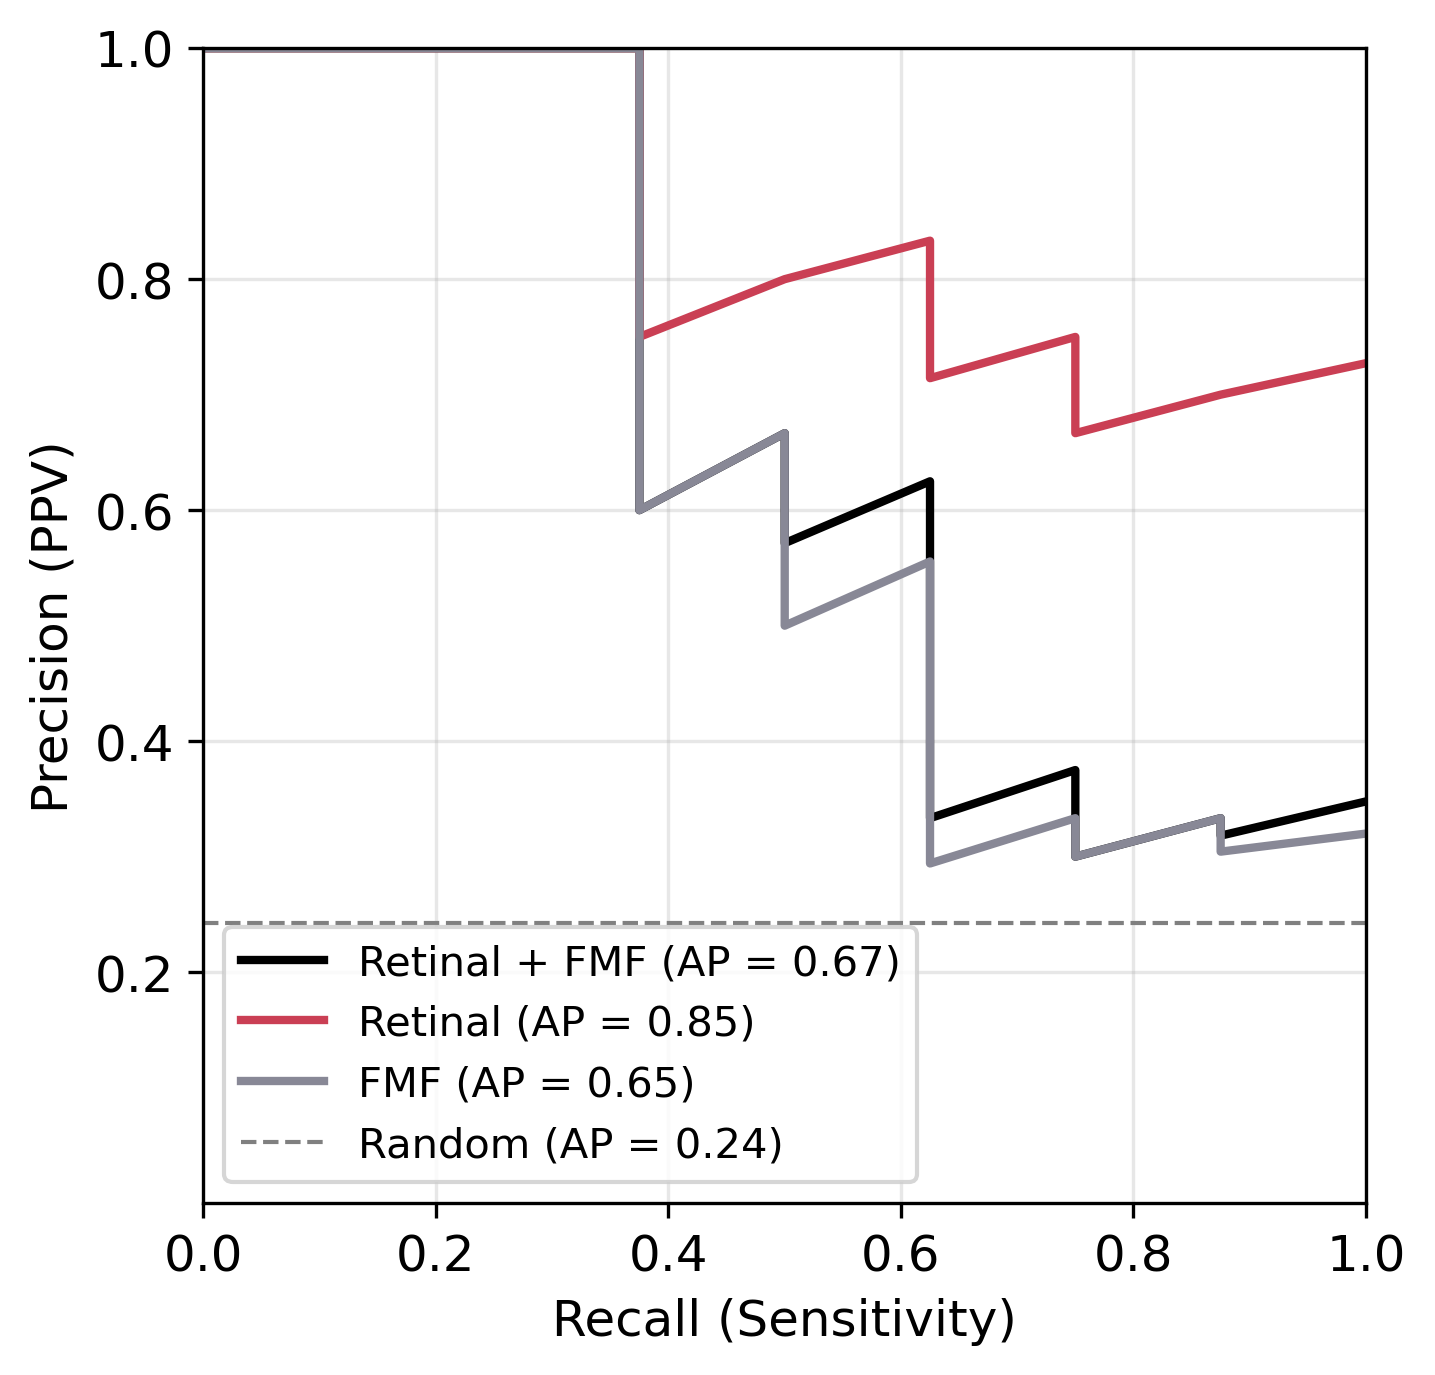

In [16]:

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))

# both
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"] + retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal + FMF", color="black");

# retinal
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")

#fmf
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_4/b_pr.pdf') 

plt.show()

In [17]:
ids = list(set(retinal_probs["id"].values) - set(final_exclusions))

In [18]:
len(retinal_probs[retinal_probs["id"].isin(ids)].dropna())

66

In [19]:
sum(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["id"].isin(pec))

13

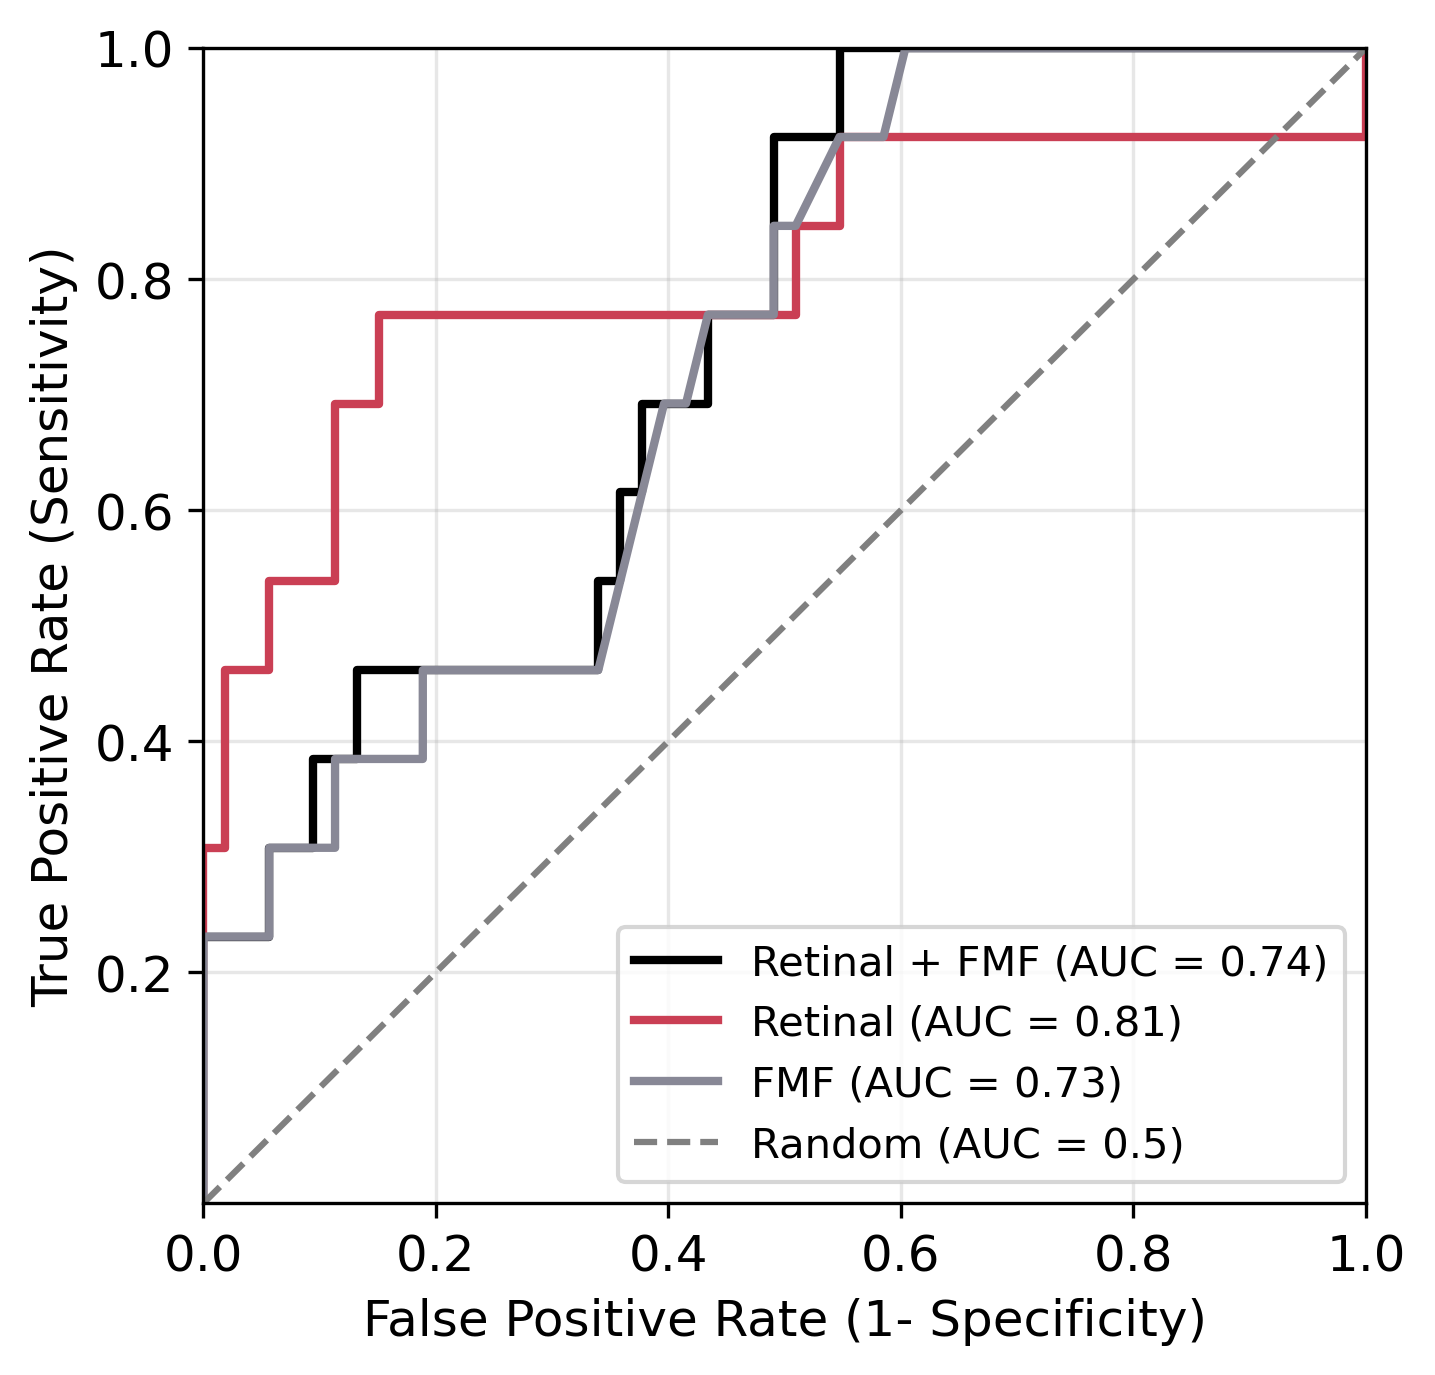

In [20]:

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))

# both
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"] + retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal + FMF", color="black");

# retinal
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")

#fmf
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_4/a_roc.pdf') 

plt.show()

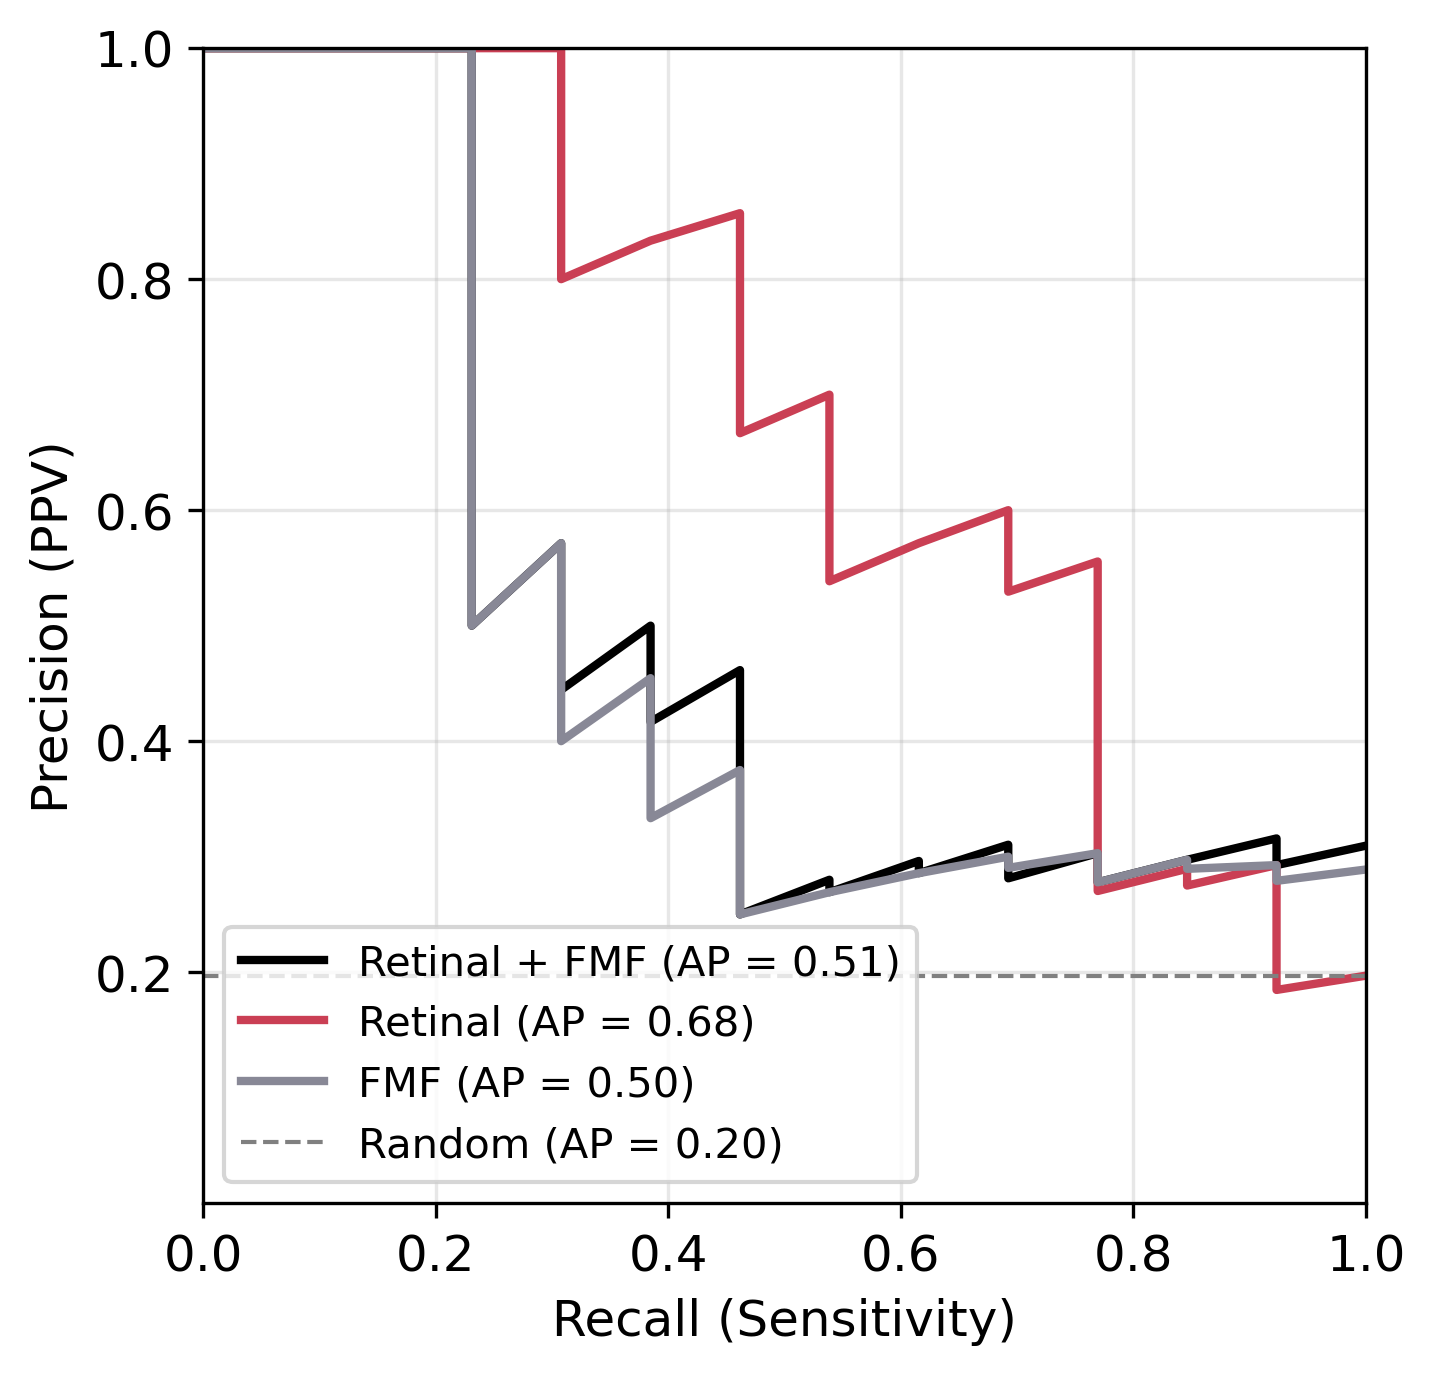

In [21]:

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))

# both
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"] + retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal + FMF", color="black");

# retinal
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")

#fmf
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["pe_before_delivery_percent"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_4/a_pr.pdf') 

plt.show()